# Modelo de Regresión — Predicción de Consumo Energético (Smart Lighting)
<br>

**Objetivo:** Desarrollar modelos de regresión para predecir el consumo energético (`energy_consumption_kwh`) en un sistema de iluminación inteligente.

**Modelos a implementar:**
- Regresión Lineal
- XGBoost Regressor
- RANSAC Regressor
- Support Vector Regression (SVR)

**Dataset:** `datos_limpios_SmartLighting.csv` (12,000 muestras, 23 columnas)

## 1. Importar las librerías necesarias

In [2]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# Preprocesamiento y selección
from sklearn.model_selection import (
    train_test_split, GridSearchCV, KFold,
    cross_validate, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

# Métricas de regresión
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

# Modelos
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

import pickle

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Cargar los datos limpios

In [3]:
# Cargar el dataset limpio
df = pd.read_csv('../data/datos_limpios_SmartLighting.csv')

print("Datos cargados:")
print(f"Dimensiones: {df.shape}")
print(f"\nColumnas:")
print(df.columns.tolist())
print(f"\nPrimeras 5 filas:")
df.head()

Datos cargados:
Dimensiones: (12000, 23)

Columnas:
['zone_id', 'ambient_light_lux', 'motion_detected', 'temperature_celsius', 'occupancy_count', 'day_of_week', 'time_of_day', 'special_event_flag', 'energy_price_per_kwh', 'prev_hour_energy_usage_kwh', 'traffic_density', 'avg_pedestrian_speed', 'adjusted_light_intensity', 'energy_consumption_kwh', 'lighting_action_class', 'hour', 'month', 'is_weekend', 'season', 'weather_condition_Clear', 'weather_condition_Cloudy', 'weather_condition_Foggy', 'weather_condition_Rainy']

Primeras 5 filas:


,zone_id,ambient_light_lux,motion_detected,temperature_celsius,occupancy_count,day_of_week,time_of_day,special_event_flag,energy_price_per_kwh,prev_hour_energy_usage_kwh,...,energy_consumption_kwh,lighting_action_class,hour,month,is_weekend,season,weather_condition_Clear,weather_condition_Cloudy,weather_condition_Foggy,weather_condition_Rainy
0,3,-0.993840,0,-0.460746,-0.257032,1,4,0,-0.946558,0.399885,...,1.144,0,0,1,0,1,0,1,0,0
1,3,-0.983895,0,-0.922368,-0.464636,1,4,0,-0.333568,-0.576984,...,2.069,1,0,1,0,1,0,1,0,0
2,7,-0.993840,0,0.449719,0.158177,1,4,0,-0.647922,-0.019562,...,1.687,1,1,1,0,1,1,0,0,0
3,2,-0.993840,1,1.301084,1.611408,1,4,0,0.884553,-1.217192,...,1.631,1,2,1,0,1,0,0,1,0
4,4,-0.993840,1,0.336310,0.573386,1,4,0,0.538764,-0.565946,...,1.737,1,2,1,0,1,1,0,0,0


## 3. Verificación de los datos preprocesados

In [4]:
# Información del dataset
print("Información del dataset:")
df.info()

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   zone_id                     12000 non-null  int64  
 1   ambient_light_lux           12000 non-null  float64
 2   motion_detected             12000 non-null  int64  
 3   temperature_celsius         12000 non-null  float64
 4   occupancy_count             12000 non-null  float64
 5   day_of_week                 12000 non-null  int64  
 6   time_of_day                 12000 non-null  int64  
 7   special_event_flag          12000 non-null  int64  
 8   energy_price_per_kwh        12000 non-null  float64
 9   prev_hour_energy_usage_kwh  12000 non-null  float64
 10  traffic_density             12000 non-null  float64
 11  avg_pedestrian_speed        12000 non-null  float64
 12  adjusted_light_intensity    12000 non-null  float64
 13  energy_consumptio

In [5]:
# Verificar valores faltantes
print("Valores faltantes:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No hay valores faltantes")
else:
    print(missing[missing > 0])

Valores faltantes:
No hay valores faltantes


Estadísticas de la variable objetivo (energy_consumption_kwh):
count    12000.000000
mean         1.483592
std          0.538188
min          0.000000
25%          1.047000
50%          1.595000
75%          1.907000
max          2.887000
Name: energy_consumption_kwh, dtype: float64


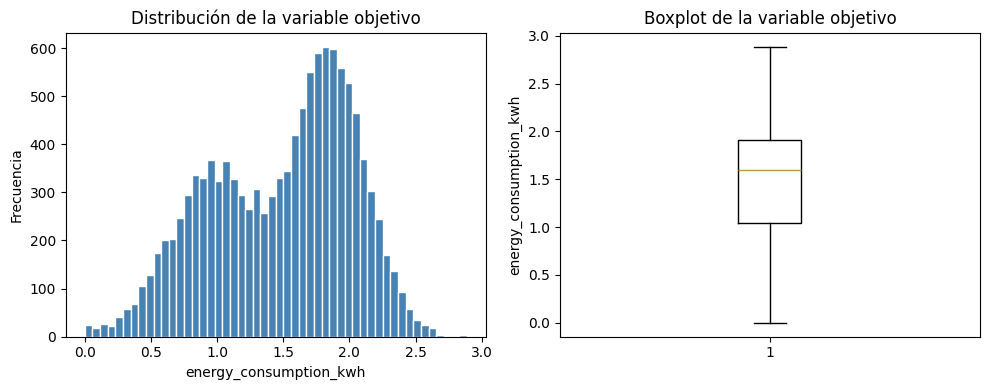

In [6]:
# Distribución de la variable objetivo
print("Estadísticas de la variable objetivo (energy_consumption_kwh):")
print(df['energy_consumption_kwh'].describe())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['energy_consumption_kwh'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('energy_consumption_kwh')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable objetivo')

plt.subplot(1, 2, 2)
plt.boxplot(df['energy_consumption_kwh'])
plt.ylabel('energy_consumption_kwh')
plt.title('Boxplot de la variable objetivo')

plt.tight_layout()
plt.show()

## 4. Preparación de los datos para modelado

### 4.1 Separar features (X) y variable objetivo (y)

In [7]:
# Separar features y target
# Se excluye 'lighting_action_class' ya que es una variable de clasificación derivada
X = df.drop(['energy_consumption_kwh', 'lighting_action_class'], axis=1)
y = df['energy_consumption_kwh']

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")
print(f"\nFeatures utilizadas ({len(X.columns)}):")
print(X.columns.tolist())

Shape de X (features): (12000, 21)
Shape de y (target): (12000,)

Features utilizadas (21):
['zone_id', 'ambient_light_lux', 'motion_detected', 'temperature_celsius', 'occupancy_count', 'day_of_week', 'time_of_day', 'special_event_flag', 'energy_price_per_kwh', 'prev_hour_energy_usage_kwh', 'traffic_density', 'avg_pedestrian_speed', 'adjusted_light_intensity', 'hour', 'month', 'is_weekend', 'season', 'weather_condition_Clear', 'weather_condition_Cloudy', 'weather_condition_Foggy', 'weather_condition_Rainy']


### 4.2 División en conjuntos de entrenamiento y prueba

In [8]:
# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("División de datos:")
print(f"  - Entrenamiento: {X_train.shape[0]} muestras ({(len(X_train)/len(X))*100:.1f}%)")
print(f"  - Prueba:        {X_test.shape[0]} muestras ({(len(X_test)/len(X))*100:.1f}%)")
print(f"\nEstadísticas de y_train:")
print(y_train.describe())
print(f"\nEstadísticas de y_test:")
print(y_test.describe())

División de datos:
  - Entrenamiento: 9600 muestras (80.0%)
  - Prueba:        2400 muestras (20.0%)

Estadísticas de y_train:
count    9600.000000
mean        1.485461
std         0.536915
min         0.000000
25%         1.052000
50%         1.595000
75%         1.907000
max         2.887000
Name: energy_consumption_kwh, dtype: float64

Estadísticas de y_test:
count    2400.000000
mean        1.476120
std         0.543295
min         0.000000
25%         1.026750
50%         1.594500
75%         1.906250
max         2.886000
Name: energy_consumption_kwh, dtype: float64


### 4.3 Escalado de features

In [9]:
# Inicializar el escalador
scaler = StandardScaler()

# Ajustar con train y transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convertir de nuevo a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test.index)

print(f"\nEstadísticas después del escalado (train):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))


Estadísticas después del escalado (train):
      zone_id  ambient_light_lux  motion_detected  temperature_celsius  \
mean     -0.0               -0.0              0.0                 -0.0   
std       1.0                1.0              1.0                  1.0   

      occupancy_count  day_of_week  time_of_day  special_event_flag  \
mean             -0.0         -0.0          0.0                 0.0   
std               1.0          1.0          1.0                 1.0   

      energy_price_per_kwh  prev_hour_energy_usage_kwh  ...  \
mean                  -0.0                        -0.0  ...   
std                    1.0                         1.0  ...   

      avg_pedestrian_speed  adjusted_light_intensity  hour  month  is_weekend  \
mean                  -0.0                      -0.0  -0.0   -0.0        -0.0   
std                    1.0                       1.0   1.0    1.0         1.0   

      season  weather_condition_Clear  weather_condition_Cloudy  \
mean    -0.0      

## 5. Modelo 1: Regresión Lineal

### 5.1 Modelo base (sin optimización)

In [ ]:
# TODO: Implementar Regresión Lineal base
pass

### 5.2 Optimización


In [ ]:
# TODO: Optimización de Regresión Lineal
pass

### 5.3 Gráfico de predicciones — Regresión Lineal

In [ ]:
# TODO: Visualización Regresión Lineal
pass

## 6. Modelo 2: XGBoost Regressor

### 6.1 Modelo base (sin optimización)

In [ ]:
# Entrenar XGBoost con parámetros por defecto
# XGBoost no requiere datos escalados
xgb_base = XGBRegressor(random_state=RANDOM_STATE)
xgb_base.fit(X_train, y_train)

# Predicciones
y_pred_xgb_base = xgb_base.predict(X_test)

# Métricas de regresión
print("RESULTADOS XGBOOST BASE")
print(f"MAE  (Error Absoluto Medio)       : {mean_absolute_error(y_test, y_pred_xgb_base):.4f}")
print(f"MSE  (Error Cuadrático Medio)      : {mean_squared_error(y_test, y_pred_xgb_base):.4f}")
print(f"RMSE (Raíz del Error Cuadrático)   : {np.sqrt(mean_squared_error(y_test, y_pred_xgb_base)):.4f}")
print(f"R²   (Coeficiente de determinación): {r2_score(y_test, y_pred_xgb_base):.4f}")
print(f"MAPE (Error Porcentual Absoluto)   : {mean_absolute_percentage_error(y_test, y_pred_xgb_base)*100:.2f}%")

RESULTADOS XGBOOST BASE
MAE  (Error Absoluto Medio)       : 0.1767
MSE  (Error Cuadrático Medio)      : 0.0493
RMSE (Raíz del Error Cuadrático)   : 0.2221
R²   (Coeficiente de determinación): 0.8328
MAPE (Error Porcentual Absoluto)   : 179461139988500.72%


### 6.2 Optimización con Grid Search

Hiperparámetros importantes de XGBoost Regressor:
- `n_estimators`: Número de árboles — más árboles mejoran el rendimiento pero aumentan el tiempo de entrenamiento
- `max_depth`: Profundidad máxima de cada árbol — controla la complejidad del modelo
- `learning_rate`: Tasa de aprendizaje — valores bajos requieren más árboles pero generalizan mejor
- `subsample`: Fracción de muestras usadas por árbol — reduce overfitting
- `colsample_bytree`: Fracción de features usadas por árbol — reduce overfitting

In [ ]:
# Definir la grilla de hiperparámetros
param_grid_xgb = {
    'n_estimators'   : [100, 200, 300],
    'max_depth'      : [3, 5, 7],
    'learning_rate'  : [0.01, 0.1, 0.3],
    'subsample'      : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

print("Grilla de hiperparámetros para XGBoost Regressor:")
print(param_grid_xgb)
total = 1
for v in param_grid_xgb.values():
    total *= len(v)
print(f"\nTotal de combinaciones: {total}")
print(f"Se usará una muestra del 30% del set de entrenamiento para reducir el tiempo")

Grilla de hiperparámetros para XGBoost Regressor:
{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.3], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8, 1.0]}

Total de combinaciones: 243
Se usará una muestra del 30% del set de entrenamiento para reducir el tiempo


In [ ]:
# Muestra del 30% para Grid Search (misma estrategia que en el modelo de anomalías)
X_train_xgb_sample, _, y_train_xgb_sample, _ = train_test_split(
    X_train, y_train,
    train_size=0.3,
    random_state=RANDOM_STATE
)

print(f"Tamaño del dataset de entrenamiento completo : {len(X_train):,}")
print(f"Tamaño de la muestra para Grid Search        : {len(X_train_xgb_sample):,}")

cv_strategy_xgb = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid_xgb,
    cv=cv_strategy_xgb,
    scoring='neg_root_mean_squared_error',  # Optimizar RMSE
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train_xgb_sample, y_train_xgb_sample)
print("\nGrid Search completado")

Tamaño del dataset de entrenamiento completo : 9,600
Tamaño de la muestra para Grid Search        : 2,880
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Grid Search completado


In [ ]:
# Mejores hiperparámetros encontrados
print("MEJORES HIPERPARÁMETROS XGBOOST REGRESSOR")
print(f"Mejores parámetros : {grid_search_xgb.best_params_}")
print(f"Mejor RMSE (CV)    : {-grid_search_xgb.best_score_:.4f}")

# Modelo final entrenado con todos los datos de entrenamiento
xgb_best = XGBRegressor(
    n_estimators     = grid_search_xgb.best_params_['n_estimators'],
    max_depth        = grid_search_xgb.best_params_['max_depth'],
    learning_rate    = grid_search_xgb.best_params_['learning_rate'],
    subsample        = grid_search_xgb.best_params_['subsample'],
    colsample_bytree = grid_search_xgb.best_params_['colsample_bytree'],
    random_state     = RANDOM_STATE
)

xgb_best.fit(X_train, y_train)
print("\nModelo final XGBoost entrenado con todos los datos de entrenamiento")

MEJORES HIPERPARÁMETROS XGBOOST REGRESSOR
Mejores parámetros : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Mejor RMSE (CV)    : 0.2034

Modelo final XGBoost entrenado con todos los datos de entrenamiento


In [ ]:
# Evaluar el mejor modelo en el conjunto de prueba
y_pred_xgb_best = xgb_best.predict(X_test)

print("RESULTADOS XGBOOST OPTIMIZADO (TEST SET)")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_xgb_best):.4f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred_xgb_best):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb_best)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred_xgb_best):.4f}")
print(f"MAPE : {mean_absolute_percentage_error(y_test, y_pred_xgb_best)*100:.2f}%")

RESULTADOS XGBOOST OPTIMIZADO (TEST SET)
MAE  : 0.1647
MSE  : 0.0428
RMSE : 0.2069
R²   : 0.8550
MAPE : 200143060074515.47%


### 6.3 Gráfico de predicciones — XGBoost

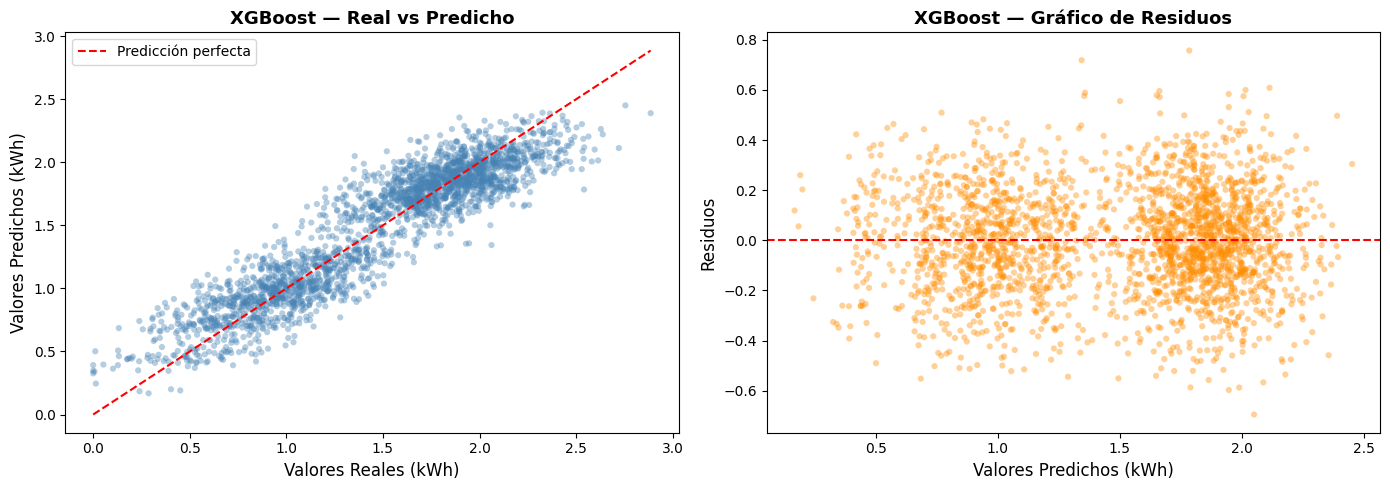

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico real vs predicho
axes[0].scatter(y_test, y_pred_xgb_best, alpha=0.4, color='steelblue', edgecolor='none', s=20)
lim = [min(y_test.min(), y_pred_xgb_best.min()),
       max(y_test.max(), y_pred_xgb_best.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales (kWh)', fontsize=12)
axes[0].set_ylabel('Valores Predichos (kWh)', fontsize=12)
axes[0].set_title('XGBoost — Real vs Predicho', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Gráfico de residuos
residuos = y_test - y_pred_xgb_best
axes[1].scatter(y_pred_xgb_best, residuos, alpha=0.4, color='darkorange', edgecolor='none', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Valores Predichos (kWh)', fontsize=12)
axes[1].set_ylabel('Residuos', fontsize=12)
axes[1].set_title('XGBoost — Gráfico de Residuos', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.4 Importancia de features (XGBoost)

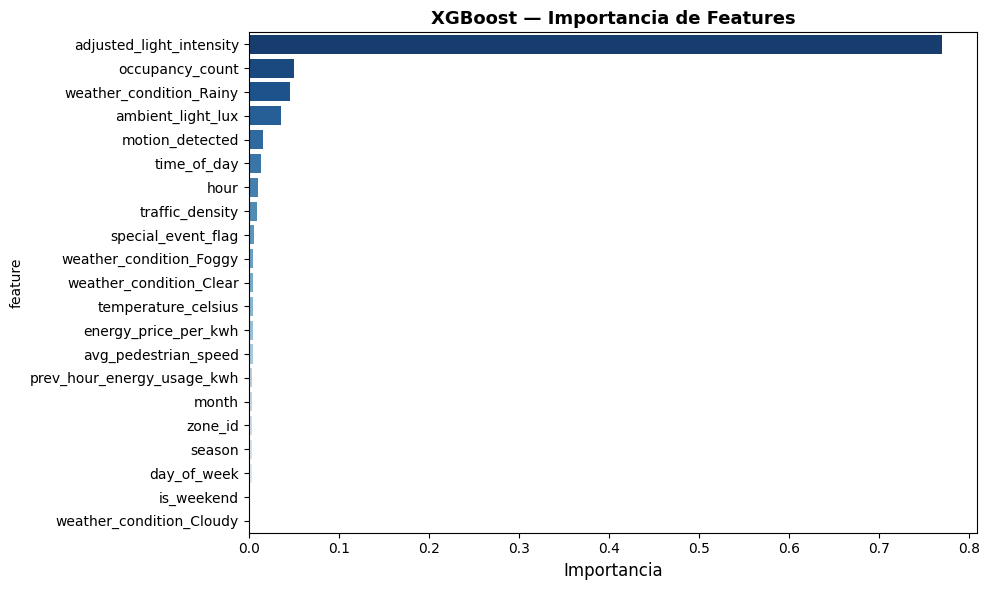

                   feature  importance
  adjusted_light_intensity    0.769953
           occupancy_count    0.050586
   weather_condition_Rainy    0.045824
         ambient_light_lux    0.035693
           motion_detected    0.016191
               time_of_day    0.013833
                      hour    0.010729
           traffic_density    0.009002
        special_event_flag    0.005560
   weather_condition_Foggy    0.004896
   weather_condition_Clear    0.004678
       temperature_celsius    0.004624
      energy_price_per_kwh    0.004378
      avg_pedestrian_speed    0.004362
prev_hour_energy_usage_kwh    0.004167
                     month    0.004143
                   zone_id    0.004067
                    season    0.003919
               day_of_week    0.003396
                is_weekend    0.000000
  weather_condition_Cloudy    0.000000


In [ ]:
# Obtener importancia de features
feature_importance_xgb = pd.DataFrame({
    'feature'   : X.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_xgb,
    x='importance', y='feature',
    palette='Blues_r'
)
plt.xlabel('Importancia', fontsize=12)
plt.title('XGBoost — Importancia de Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(feature_importance_xgb.to_string(index=False))

## 7. Modelo 3: RANSAC Regressor
RANSAC usa datos escalados porque su estimador base es LinearRegression.
1. Se selecciona aleatoriamente un subconjunto mínimo de muestras (min_samples)
2. Se ajusta el estimador base (LinearRegression) con ese subconjunto
3. Se clasifica las demás muestras como "inliers" si su error residual es menor al umbral (residual_threshold)
4. Se repite el proceso (max_trials veces) y conserva el modelo con más inliers
5. Se reajusta el modelo final usando todos los inliers encontrados

### 7.1 Modelo base (sin optimización)

In [ ]:
t0 = time.time() 
ransac_base = RANSACRegressor( 
    estimator    = LinearRegression(), # RANSAC usa datos escalados porque su estimador base es LinearRegression
    random_state = RANDOM_STATE
)
ransac_base.fit(X_train_scaled, y_train)

#Se muestra el tiempo de entrenamiento y la cantidad de inliers/outliers detectados
inlier_mask = ransac_base.inlier_mask_
n_inliers   = inlier_mask.sum()
n_outliers  = (~inlier_mask).sum()
print(f"Tiempo de entrenamiento: {time.time()-t0:.2f}s")
print(f"  Inliers  (usados)    : {n_inliers:,} ({n_inliers/len(X_train_scaled)*100:.1f}%)")
print(f"  Outliers (ignorados) : {n_outliers:,} ({n_outliers/len(X_train_scaled)*100:.1f}%)")


y_pred_ransac_base = ransac_base.predict(X_test_scaled) #Se predice con el modelo RANSAC entrenado con datos escalados

#Métricas de regresión
print("\nRESULTADOS RANSAC BASE")
print(f"MAE  (Error Absoluto Medio)        : {mean_absolute_error(y_test, y_pred_ransac_base):.4f}")
print(f"MSE  (Error Cuadrático Medio)      : {mean_squared_error(y_test, y_pred_ransac_base):.4f}")
print(f"RMSE (Raíz del Error Cuadrático)   : {np.sqrt(mean_squared_error(y_test, y_pred_ransac_base)):.4f}")
print(f"R2   (Coeficiente de determinación): {r2_score(y_test, y_pred_ransac_base):.4f}")
print(f"MAPE (Error Porcentual Absoluto)   : {mean_absolute_percentage_error(y_test, y_pred_ransac_base)*100:.2f}%")

Tiempo de entrenamiento: 0.22s
  Inliers  (usados)    : 7,865 (81.9%)
  Outliers (ignorados) : 1,735 (18.1%)

RESULTADOS RANSAC BASE
MAE  (Error Absoluto Medio)        : 0.1742
MSE  (Error Cuadrático Medio)      : 0.0481
RMSE (Raíz del Error Cuadrático)   : 0.2192
R2   (Coeficiente de determinación): 0.8371
MAPE (Error Porcentual Absoluto)   : 219976114006425.50%


### 7.2 Optimización

In [ ]:
#Se muestra la grilla de hiperparámetros que se va a explorar para RANSAC, 
#con una muestra del 30% del set de entrenamiento para reducir el tiempo de búsqueda
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

X_train_ransac_sample, _, y_train_ransac_sample, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=0.3,
    random_state=RANDOM_STATE
)

print(f"Tamaño del dataset de entrenamiento completo : {len(X_train_scaled):,}")
print(f"Tamaño de la muestra para la búsqueda        : {len(X_train_ransac_sample):,}")

param_dist_ransac = {
    'min_samples'        : uniform(0.1, 0.8),   #Fracción mínima de muestras para ajustar el modelo base
    'residual_threshold' : uniform(0.05, 1.0),  #Umbral de error para clasificar una muestra como inlier
    'max_trials'         : randint(50, 500),    #Número máximo de iteraciones aleatorias
    'max_skips'          : randint(10, 200),    #Máximo de iteraciones que se pueden saltar
}

print("\nGrilla de hiperparámetros para RANSAC:")
for k, v in param_dist_ransac.items():
    print(f"  {k}: {v}")
print("\nRandomizedSearchCV explorará 30 combinaciones aleatorias")

cv_strategy_ransac = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
#Se usa una validación cruzada de 3 folds para reducir el tiempo de búsqueda
random_search_ransac = RandomizedSearchCV(
    estimator=RANSACRegressor(
        estimator    = LinearRegression(),
        random_state = RANDOM_STATE
    ),
    param_distributions = param_dist_ransac,
    n_iter              = 30,
    cv                  = cv_strategy_ransac,
    scoring             = 'neg_root_mean_squared_error',  #Se optimiza RMSE
    n_jobs              = -1,
    random_state        = RANDOM_STATE,
    verbose             = 2
)

t0 = time.time()
random_search_ransac.fit(X_train_ransac_sample, y_train_ransac_sample)
print(f"\nBúsqueda completada en {(time.time()-t0)/60:.1f} min")

# Mejores hiperparámetros encontrados
print("\nMEJORES HIPERPARÁMETROS RANSAC")
for param, value in random_search_ransac.best_params_.items():
    print(f"  {param:25s}: {value:.4f}" if isinstance(value, float) else f"  {param:25s}: {value}")
print(f"  Mejor RMSE (CV)          : {-random_search_ransac.best_score_:.4f}")

# Modelo final entrenado con todos los datos de entrenamiento
ransac_best = RANSACRegressor(
    estimator          = LinearRegression(),
    min_samples        = random_search_ransac.best_params_['min_samples'],
    residual_threshold = random_search_ransac.best_params_['residual_threshold'],
    max_trials         = random_search_ransac.best_params_['max_trials'],
    max_skips          = random_search_ransac.best_params_['max_skips'],
    random_state       = RANDOM_STATE
)
ransac_best.fit(X_train_scaled, y_train)
print("\nModelo final RANSAC entrenado con todos los datos de entrenamiento")
# Se muestra el tiempo de entrenamiento y la cantidad de inliers/outliers detectados
inlier_mask_best = ransac_best.inlier_mask_
n_inliers_best   = inlier_mask_best.sum()
n_outliers_best  = (~inlier_mask_best).sum()
print(f"  Inliers  (usados)    : {n_inliers_best:,} ({n_inliers_best/len(X_train_scaled)*100:.1f}%)")
print(f"  Outliers (ignorados) : {n_outliers_best:,} ({n_outliers_best/len(X_train_scaled)*100:.1f}%)")

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_ransac_best = ransac_best.predict(X_test_scaled)

print("\nRESULTADOS RANSAC OPTIMIZADO (TEST SET)")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_ransac_best):.4f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred_ransac_best):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_ransac_best)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred_ransac_best):.4f}")
print(f"MAPE : {mean_absolute_percentage_error(y_test, y_pred_ransac_best)*100:.2f}%")

Tamaño del dataset de entrenamiento completo : 9,600
Tamaño de la muestra para la búsqueda        : 2,880

Grilla de hiperparámetros para RANSAC:
  min_samples: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001EA30030CE0>
  residual_threshold: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001EA2FFC6840>
  max_trials: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001EA33CD3E00>
  max_skips: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001EA2FFA8AA0>

RandomizedSearchCV explorará 30 combinaciones aleatorias
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Búsqueda completada en 0.1 min

MEJORES HIPERPARÁMETROS RANSAC
  max_skips                : 170
  max_trials               : 363
  min_samples              : 0.5198
  residual_threshold       : 0.4819
  Mejor RMSE (CV)          : 0.2011

Modelo final RANSAC entrenado con todos los datos de entrenamiento
  Inliers  (usados)    : 

### 7.3 Gráfico de predicciones — RANSAC

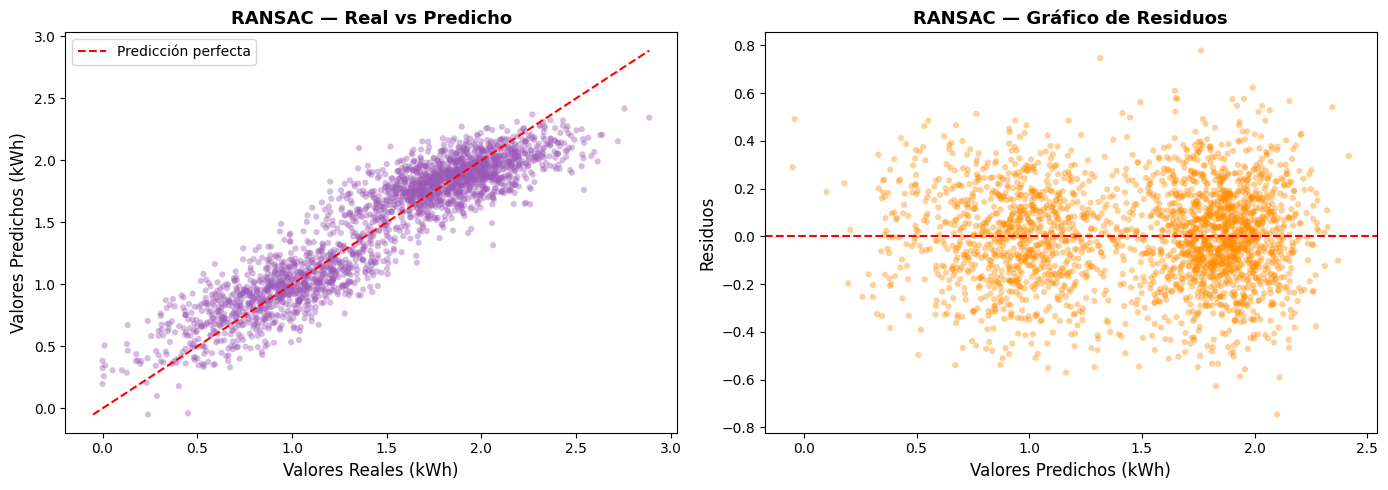

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico real vs predicho
axes[0].scatter(y_test, y_pred_ransac_best, alpha=0.4, color='#9b59b6', edgecolor='none', s=20)
lim = [min(y_test.min(), y_pred_ransac_best.min()),
       max(y_test.max(), y_pred_ransac_best.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales (kWh)', fontsize=12)
axes[0].set_ylabel('Valores Predichos (kWh)', fontsize=12)
axes[0].set_title('RANSAC — Real vs Predicho', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Gráfico de residuos
residuos_ransac = y_test - y_pred_ransac_best
axes[1].scatter(y_pred_ransac_best, residuos_ransac, alpha=0.4, color='darkorange', edgecolor='none', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Valores Predichos (kWh)', fontsize=12)
axes[1].set_ylabel('Residuos', fontsize=12)
axes[1].set_title('RANSAC — Gráfico de Residuos', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Modelo 4: Support Vector Regression (SVR)

### 8.1 Modelo base (sin optimización)

Parámetros del modelo base:
- kernel='rbf': Kernel gaussiano — captura relaciones no lineales entre features
- C=1.0: Parámetro de regularización por defecto
- epsilon=0.1: Margen de tolerancia por defecto
- SVR **requiere** datos escalados — se usan X_train_scaled y X_test_scaled

In [10]:
# Entrenar SVR con parámetros por defecto
# Datos escalados: X_train_scaled, X_test_scaled
t0 = time.time()
svr_base = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_base.fit(X_train_scaled, y_train)

# Predicciones
y_pred_svr_base = svr_base.predict(X_test_scaled)

print("RESULTADOS SVR BASE (kernel=rbf, C=1.0, epsilon=0.1)")
print(f"MAE  (Error Absoluto Medio)       : {mean_absolute_error(y_test, y_pred_svr_base):.4f}")
print(f"MSE  (Error Cuadrático Medio)      : {mean_squared_error(y_test, y_pred_svr_base):.4f}")
print(f"RMSE (Raíz del Error Cuadrático)   : {np.sqrt(mean_squared_error(y_test, y_pred_svr_base)):.4f}")
print(f"R²   (Coeficiente de determinación): {r2_score(y_test, y_pred_svr_base):.4f}")
print(f"MAPE (Error Porcentual Absoluto)   : {mean_absolute_percentage_error(y_test, y_pred_svr_base)*100:.2f}%")
print(f"Tiempo de entrenamiento            : {time.time()-t0:.2f}s")

RESULTADOS SVR BASE (kernel=rbf, C=1.0, epsilon=0.1)
MAE  (Error Absoluto Medio)       : 0.1742
MSE  (Error Cuadrático Medio)      : 0.0479
RMSE (Raíz del Error Cuadrático)   : 0.2188
R²   (Coeficiente de determinación): 0.8378
MAPE (Error Porcentual Absoluto)   : 221001237281195.03%
Tiempo de entrenamiento            : 6.96s


### 8.2 Optimización con Grid Search
Hiperparámetros importantes de SVR:
- C: Parámetro de regularización — valores altos reducen el margen pero penalizan más los errores fuera del tubo
- epsilon: Ancho del tubo de tolerancia — predicciones dentro de este margen no reciben penalización
- kernel: Función de transformación del espacio de features (`rbf` captura relaciones no lineales; `linear` y `poly` para otras estructuras)
- gamma: Parámetro de la función RBF — 'scale' usa 1/(n_features × Var(X)); 'auto' usa 1/n_features

In [13]:
# Definir los hiperparámetros
param_grid_svr = {
    'C'      : [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1.0],
    'kernel' : ['rbf', 'linear'],
    'gamma'  : ['scale', 'auto']
}

print("Grilla de hiperparámetros para SVR:")
print(param_grid_svr)
total = 1
for v in param_grid_svr.values():
    total *= len(v)
print(f"\nTotal de combinaciones: {total}")
print(f"Se usará una muestra del 30% del set de entrenamiento para reducir el tiempo")

Grilla de hiperparámetros para SVR:
{'C': [0.1, 1, 10, 100], 'epsilon': [0.01, 0.1, 0.5, 1.0], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}

Total de combinaciones: 64
Se usará una muestra del 30% del set de entrenamiento para reducir el tiempo


In [14]:
# Muestra del 30% para Grid Search
X_train_svr_sample, _, y_train_svr_sample, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=0.3,
    random_state=RANDOM_STATE
)

print(f"Tamaño del dataset de entrenamiento completo : {len(X_train_scaled):,}")
print(f"Tamaño de la muestra para Grid Search        : {len(X_train_svr_sample):,}")

cv_strategy_svr = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

t0 = time.time()
grid_search_svr = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=cv_strategy_svr,
    scoring='neg_root_mean_squared_error',   # Optimizar RMSE
    n_jobs=-1,
    verbose=2
)

grid_search_svr.fit(X_train_svr_sample, y_train_svr_sample)
print(f"\nGrid Search completado en {time.time()-t0:.1f}s")

Tamaño del dataset de entrenamiento completo : 9,600
Tamaño de la muestra para Grid Search        : 2,880
Fitting 5 folds for each of 64 candidates, totalling 320 fits

Grid Search completado en 716.7s


In [15]:
# Mejores hiperparámetros encontrados
print("MEJORES HIPERPARÁMETROS SVR")
print(f"Mejores parámetros : {grid_search_svr.best_params_}")
print(f"Mejor RMSE (CV)    : {-grid_search_svr.best_score_:.4f}")

# Modelo final entrenado con TODOS los datos de entrenamiento escalados
t0 = time.time()
svr_best = SVR(
    C       = grid_search_svr.best_params_['C'],
    epsilon = grid_search_svr.best_params_['epsilon'],
    kernel  = grid_search_svr.best_params_['kernel'],
    gamma   = grid_search_svr.best_params_['gamma']
)
svr_best.fit(X_train_scaled, y_train)
print(f"\nModelo final SVR entrenado con todos los datos de entrenamiento en {time.time()-t0:.1f}s")

MEJORES HIPERPARÁMETROS SVR
Mejores parámetros : {'C': 0.1, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
Mejor RMSE (CV)    : 0.2012

Modelo final SVR entrenado con todos los datos de entrenamiento en 8.4s


In [16]:
# Evaluar el mejor modelo en el conjunto de prueba
y_pred_svr_best = svr_best.predict(X_test_scaled)

print("RESULTADOS SVR OPTIMIZADO (TEST SET)")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_svr_best):.4f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred_svr_best):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_svr_best)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred_svr_best):.4f}")
print(f"MAPE : {mean_absolute_percentage_error(y_test, y_pred_svr_best)*100:.2f}%")

RESULTADOS SVR OPTIMIZADO (TEST SET)
MAE  : 0.1639
MSE  : 0.0426
RMSE : 0.2063
R²   : 0.8557
MAPE : 172314218627031.62%


### 8.3 Gráfico de predicciones — SVR

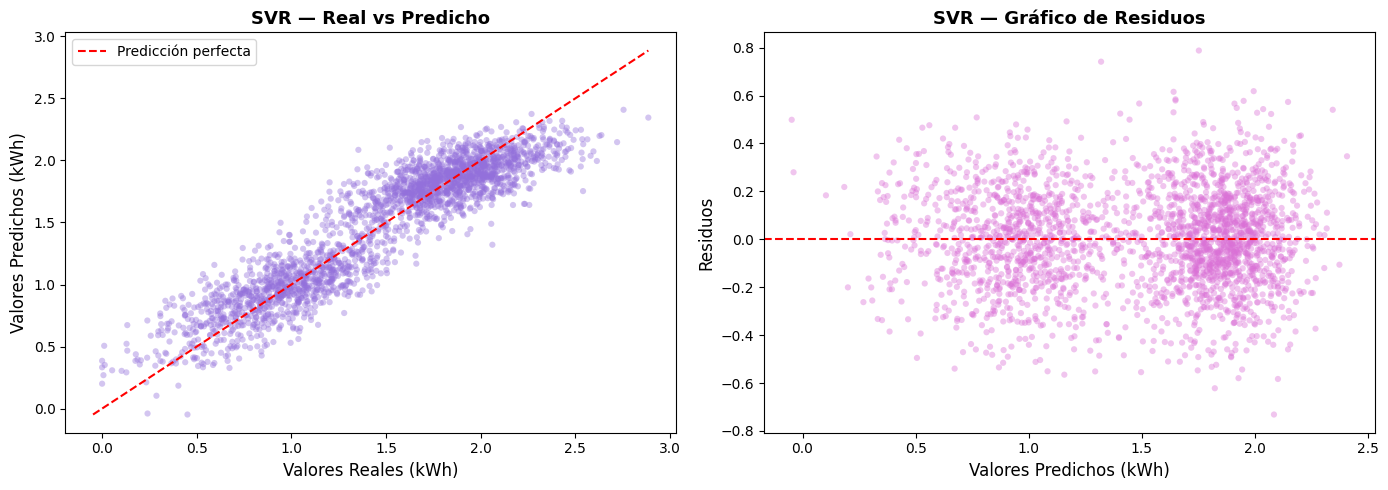

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico real vs predicho
axes[0].scatter(y_test, y_pred_svr_best, alpha=0.4, color='mediumpurple', edgecolor='none', s=20)
lim = [min(y_test.min(), y_pred_svr_best.min()),
       max(y_test.max(), y_pred_svr_best.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales (kWh)', fontsize=12)
axes[0].set_ylabel('Valores Predichos (kWh)', fontsize=12)
axes[0].set_title('SVR — Real vs Predicho', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Gráfico de residuos
residuos_svr = y_test - y_pred_svr_best
axes[1].scatter(y_pred_svr_best, residuos_svr, alpha=0.4, color='orchid', edgecolor='none', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Valores Predichos (kWh)', fontsize=12)
axes[1].set_ylabel('Residuos', fontsize=12)
axes[1].set_title('SVR — Gráfico de Residuos', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Comparación de modelos: Regresión Lineal vs XGBoost vs RANSAC vs SVR

In [ ]:
# TODO: Tabla comparativa de los 4 modelos (base + optimizado)
# Métricas: MAE, MSE, RMSE, R², MAPE
pass

In [ ]:
# TODO: Visualización comparativa (barras por métrica)
pass

## 10. Selección de Características y Validación Cruzada — Regresión Lineal

TODO: Implementar selección de características para Regresión Lineal

### 10.1 Regresión Lineal — Selección de características

In [ ]:
# TODO: Selección de características — Regresión Lineal
pass

### 10.2 Validación cruzada — Regresión Lineal con todas las features

In [ ]:
# TODO: CV Regresión Lineal completa
pass

### 10.3 Validación cruzada — Regresión Lineal con selección de características

In [ ]:
# TODO: CV Regresión Lineal con features seleccionadas
pass

### 10.4 Comparación de la validación cruzada — Regresión Lineal

In [ ]:
# TODO: Tabla comparativa CV Regresión Lineal
pass

## 11. Selección de Características y Validación Cruzada — XGBoost

Se aplica selección por importancia de features (umbral = media) usando `SelectFromModel`.
XGBoost calcula internamente cuánto contribuye cada feature a la reducción del error;
se conservan las que superan el promedio de importancia.

### 11.1 XGBoost — Selección por Importancia de Features (Umbral = media)

`SelectFromModel` con `threshold='mean'` conserva únicamente las features cuya importancia
supera el promedio de todas las importancias.

In [ ]:
# SelectFromModel con threshold='mean'
selector_xgb = SelectFromModel(
    estimator = xgb_best,
    threshold = 'mean',  # umbral = importancia promedio
    prefit    = True     # xgb_best ya está entrenado
)

# Aplicar selección a train y test
X_train_xgb_fs = selector_xgb.transform(X_train)
X_test_xgb_fs  = selector_xgb.transform(X_test)

# Identificar features seleccionadas y descartadas
features_seleccionadas_xgb = X.columns[selector_xgb.get_support()].tolist()
features_descartadas_xgb   = X.columns[~selector_xgb.get_support()].tolist()

umbral_xgb = xgb_best.feature_importances_.mean()
print(f"Umbral de importancia (promedio): {umbral_xgb:.4f}")

print(f"\nFeatures SELECCIONADAS ({len(features_seleccionadas_xgb)}):")
for f in features_seleccionadas_xgb:
    imp = xgb_best.feature_importances_[list(X.columns).index(f)]
    print(f"  {f:35s}  importancia: {imp:.4f}")

print(f"\nFeatures DESCARTADAS ({len(features_descartadas_xgb)}):")
for f in features_descartadas_xgb:
    imp = xgb_best.feature_importances_[list(X.columns).index(f)]
    print(f"  {f:35s}  importancia: {imp:.4f}")

Umbral de importancia (promedio): 0.0476

Features SELECCIONADAS (2):
  occupancy_count                      importancia: 0.0506
  adjusted_light_intensity             importancia: 0.7700

Features DESCARTADAS (19):
  zone_id                              importancia: 0.0041
  ambient_light_lux                    importancia: 0.0357
  motion_detected                      importancia: 0.0162
  temperature_celsius                  importancia: 0.0046
  day_of_week                          importancia: 0.0034
  time_of_day                          importancia: 0.0138
  special_event_flag                   importancia: 0.0056
  energy_price_per_kwh                 importancia: 0.0044
  prev_hour_energy_usage_kwh           importancia: 0.0042
  traffic_density                      importancia: 0.0090
  avg_pedestrian_speed                 importancia: 0.0044
  hour                                 importancia: 0.0107
  month                                importancia: 0.0041
  is_weekend     

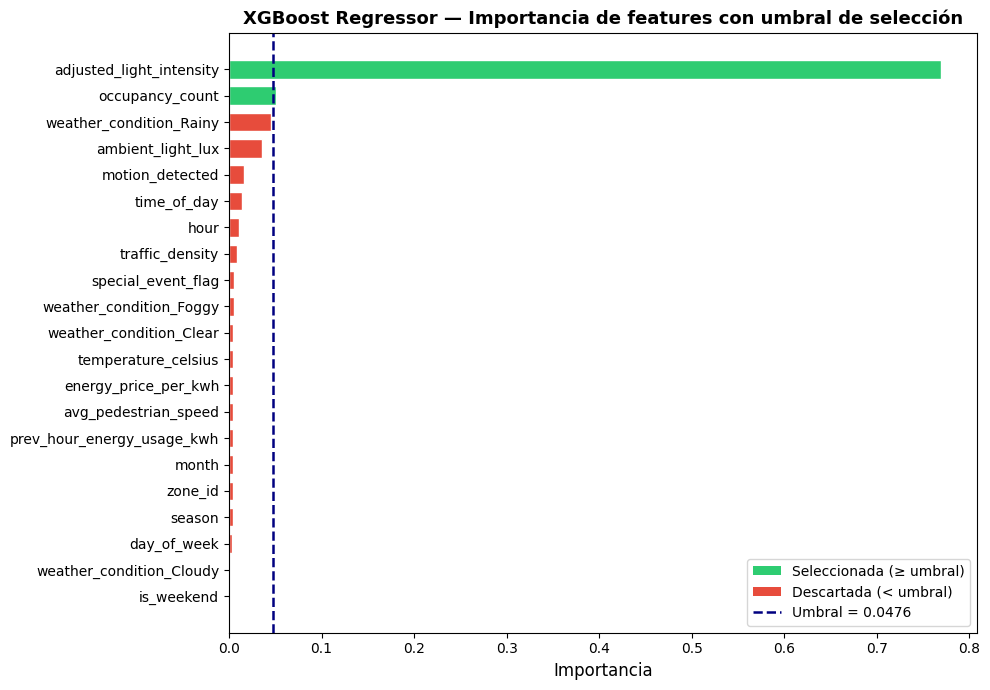

In [ ]:
# Gráfica de importancias con línea de umbral
feature_imp_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=True)

colores = ['#2ecc71' if imp >= umbral_xgb else '#e74c3c'
           for imp in feature_imp_df['importance']]

plt.figure(figsize=(10, 7))
plt.barh(feature_imp_df['feature'], feature_imp_df['importance'],
         color=colores, edgecolor='white', height=0.7)
plt.axvline(x=umbral_xgb, color='navy', linestyle='--', linewidth=1.8,
            label=f'Umbral (mean = {umbral_xgb:.4f})')
plt.xlabel('Importancia', fontsize=12)
plt.title('XGBoost Regressor — Importancia de features con umbral de selección',
          fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Seleccionada (≥ umbral)'),
    Patch(facecolor='#e74c3c', label='Descartada (< umbral)'),
    plt.Line2D([0], [0], color='navy', linestyle='--',
               linewidth=1.8, label=f'Umbral = {umbral_xgb:.4f}')
]
plt.legend(handles=legend_elements, fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# Reentrenar XGBoost con los hiperparámetros ya optimizados y las features seleccionadas
xgb_fs = XGBRegressor(
    n_estimators     = grid_search_xgb.best_params_['n_estimators'],
    max_depth        = grid_search_xgb.best_params_['max_depth'],
    learning_rate    = grid_search_xgb.best_params_['learning_rate'],
    subsample        = grid_search_xgb.best_params_['subsample'],
    colsample_bytree = grid_search_xgb.best_params_['colsample_bytree'],
    random_state     = RANDOM_STATE
)
xgb_fs.fit(X_train_xgb_fs, y_train)

# Predicciones
y_pred_xgb_fs = xgb_fs.predict(X_test_xgb_fs)

n_features_total = X_train.shape[1]
print("RESULTADOS XGBOOST — CON SELECCIÓN POR IMPORTANCIA")
print(f"Features usadas : {len(features_seleccionadas_xgb)} de {n_features_total}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_xgb_fs):.4f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred_xgb_fs):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb_fs)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred_xgb_fs):.4f}")
print(f"MAPE : {mean_absolute_percentage_error(y_test, y_pred_xgb_fs)*100:.2f}%")

RESULTADOS XGBOOST — CON SELECCIÓN POR IMPORTANCIA
Features usadas : 2 de 21
MAE  : 0.1651
MSE  : 0.0432
RMSE : 0.2077
R²   : 0.8537
MAPE : 218788228934334.78%


In [ ]:
# Comparación: XGBoost completo vs XGBoost con selección por importancia
comparacion_xgb_fs = pd.DataFrame({
    'Modelo'      : [
        'XGBoost Optimizado (todas las features)',
        f'XGBoost + Importancia ({len(features_seleccionadas_xgb)} features, umbral=mean)'
    ],
    'N° Features' : [n_features_total, len(features_seleccionadas_xgb)],
    'MAE'         : [mean_absolute_error(y_test, y_pred_xgb_best),
                     mean_absolute_error(y_test, y_pred_xgb_fs)],
    'RMSE'        : [np.sqrt(mean_squared_error(y_test, y_pred_xgb_best)),
                     np.sqrt(mean_squared_error(y_test, y_pred_xgb_fs))],
    'R²'          : [r2_score(y_test, y_pred_xgb_best),
                     r2_score(y_test, y_pred_xgb_fs)],
    'MAPE (%)'    : [mean_absolute_percentage_error(y_test, y_pred_xgb_best)*100,
                     mean_absolute_percentage_error(y_test, y_pred_xgb_fs)*100]
})

print("Comparación XGBoost — todas las features vs Selección por Importancia:")
print(comparacion_xgb_fs.round(4).to_string(index=False))

Comparación XGBoost — todas las features vs Selección por Importancia:
                                         Modelo  N° Features    MAE   RMSE     R²     MAPE (%)
        XGBoost Optimizado (todas las features)           21 0.1647 0.2069 0.8550 2.001431e+14
XGBoost + Importancia (2 features, umbral=mean)            2 0.1651 0.2077 0.8537 2.187882e+14


### 11.2 Validación cruzada — XGBoost con todas las features

In [ ]:
cv_5fold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring_metrics_reg = {
    'mae'  : 'neg_mean_absolute_error',
    'rmse' : 'neg_root_mean_squared_error',
    'r2'   : 'r2'
}

t0 = time.time()

cv_results_xgb_completo = cross_validate(
    xgb_best,
    X_train, y_train,           # XGBoost no requiere datos escalados
    cv=cv_5fold,
    scoring=scoring_metrics_reg,
    n_jobs=-1,
    return_train_score=True     # Permite detectar overfitting
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — XGBOOST TODAS LAS FEATURES")
for metrica, key in [('MAE', 'mae'), ('RMSE', 'rmse'), ('R²', 'r2')]:
    val_scores   = cv_results_xgb_completo[f'test_{key}']
    train_scores = cv_results_xgb_completo[f'train_{key}']
    # MAE y RMSE vienen en negativo (neg_*), se invierten para mostrar el valor real
    factor = -1 if key in ['mae', 'rmse'] else 1
    print(f"  {metrica:5s} | Val: {factor*val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {factor*train_scores.mean():.4f} ± {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


RESULTADOS VALIDACIÓN CRUZADA — XGBOOST TODAS LAS FEATURES
  MAE   | Val: 0.1606 ± 0.0016 | Train: 0.1533 ± 0.0005
  RMSE  | Val: 0.2009 ± 0.0027 | Train: 0.1919 ± 0.0007
  R²    | Val: 0.8598 ± 0.0048 | Train: 0.8723 ± 0.0012

Tiempo: 0.7s


### 11.3 Validación cruzada — XGBoost con Selección por Importancia

In [ ]:
t0 = time.time()
# Validación cruzada con el modelo XGBoost entrenado solo con las features
# seleccionadas por importancia (umbral = mean)
cv_results_xgb_fs = cross_validate(
    xgb_fs,
    X_train_xgb_fs, y_train,    # Subconjunto ya transformado por SelectFromModel
    cv=cv_5fold,
    scoring=scoring_metrics_reg,
    n_jobs=-1,
    return_train_score=True
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — XGBOOST CON SELECCIÓN POR IMPORTANCIA")
for metrica, key in [('MAE', 'mae'), ('RMSE', 'rmse'), ('R²', 'r2')]:
    val_scores   = cv_results_xgb_fs[f'test_{key}']
    train_scores = cv_results_xgb_fs[f'train_{key}']
    factor = -1 if key in ['mae', 'rmse'] else 1
    print(f"  {metrica:5s} | Val: {factor*val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {factor*train_scores.mean():.4f} ± {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


RESULTADOS VALIDACIÓN CRUZADA — XGBOOST CON SELECCIÓN POR IMPORTANCIA
  MAE   | Val: 0.1608 ± 0.0017 | Train: 0.1586 ± 0.0005
  RMSE  | Val: 0.2011 ± 0.0027 | Train: 0.1983 ± 0.0007
  R²    | Val: 0.8596 ± 0.0048 | Train: 0.8635 ± 0.0012

Tiempo: 0.5s


### 11.4 Comparación de la validación cruzada — XGBoost

In [ ]:
metricas_cv  = ['mae', 'rmse', 'r2']
nombres_show = ['MAE', 'RMSE', 'R²']
# Las métricas neg_* se invierten para mostrar valores positivos
factores     = [-1, -1, 1]

resumen_cv_xgb = pd.DataFrame({
    'Métrica'            : nombres_show,
    'XGB_Completo_Media' : [factores[i] * cv_results_xgb_completo[f'test_{m}'].mean()
                            for i, m in enumerate(metricas_cv)],
    'XGB_Completo_Std'   : [cv_results_xgb_completo[f'test_{m}'].std()
                            for m in metricas_cv],
    'XGB_FS_Media'       : [factores[i] * cv_results_xgb_fs[f'test_{m}'].mean()
                            for i, m in enumerate(metricas_cv)],
    'XGB_FS_Std'         : [cv_results_xgb_fs[f'test_{m}'].std()
                            for m in metricas_cv],
})

print("COMPARACIÓN VALIDACIÓN CRUZADA — XGBoost Completo vs XGBoost + Importancia")
print(resumen_cv_xgb.round(4).to_string(index=False))

COMPARACIÓN VALIDACIÓN CRUZADA — XGBoost Completo vs XGBoost + Importancia
Métrica  XGB_Completo_Media  XGB_Completo_Std  XGB_FS_Media  XGB_FS_Std
    MAE              0.1606            0.0016        0.1608      0.0017
   RMSE              0.2009            0.0027        0.2011      0.0027
     R²              0.8598            0.0048        0.8596      0.0048



## 12. Selección de Características y Validación Cruzada — RANSAC

Se aplica selección hacia adelante (Forward Feature Selection) usando el RANSAC ya optimizado como estimador base.
Se evalúa de 1 a n_features y se elige el número óptimo con base en la curva de RMSE, siguiendo el mismo patrón aplicado con XGBoost.

### 12.1 RANSAC — Selección de características

Features preseleccionadas por correlación (top 10):
   adjusted_light_intensity              corr: 0.9193
   ambient_light_lux                     corr: 0.4391
   time_of_day                           corr: 0.3852
   motion_detected                       corr: 0.3165
   occupancy_count                       corr: 0.2968
   traffic_density                       corr: 0.2050
   weather_condition_Rainy               corr: 0.1770
   weather_condition_Clear               corr: 0.1296
   weather_condition_Foggy               corr: 0.0960
   special_event_flag                    corr: 0.0737

Features en búsqueda    : 10 (de 21 totales)
Muestra para selección  : 960 muestras (10 %)

Explorando Forward Selection con RANSAC (1 a 10 features)...
[ 1/10] +'adjusted_light_intensity'  ->  RMSE (CV): 0.2163  (0.4s)
[ 2/10] +'occupancy_count'  ->  RMSE (CV): 0.2036  (0.2s)
[ 3/10] +'motion_detected'  ->  RMSE (CV): 0.2021  (0.2s)
[ 4/10] +'ambient_light_lux'  ->  RMSE (CV): 0.2032  (0.2s)
[ 5/10] +'w

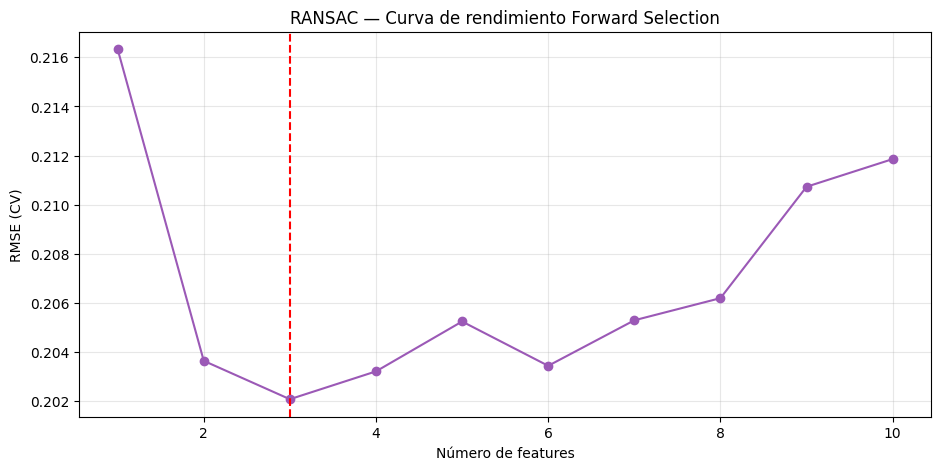


RESULTADOS FINALES RANSAC
MAE  : 0.1647
RMSE : 0.2078
R²   : 0.8536


In [ ]:
correlaciones = X_train_scaled.corrwith(y_train).abs().sort_values(ascending=False)
top_features  = correlaciones.head(10).index.tolist()

print(f"Features preseleccionadas por correlación (top 10):")
# Se muestran las 10 features con mayor correlación absoluta con la variable objetivo
for f in top_features:
    print(f"   {f:35s}   corr: {correlaciones[f]:.4f}")

#Para reducir el tiempo de búsqueda, se toma una muestra del 10% del set de entrenamiento con las features preseleccionadas
X_rfe_ransac_sample, _, y_rfe_ransac_sample, _ = train_test_split(
    X_train_scaled[top_features], y_train,
    train_size=0.10,
    random_state=RANDOM_STATE
)
#Para asegurar que el número de muestras sea suficiente para el modelo RANSAC, se verifica que min_samples sea al menos n_features + 1
n_features_total  = X_train_scaled.shape[1]
n_features_subset = len(top_features)
print(f"\nFeatures en búsqueda    : {n_features_subset} (de {n_features_total} totales)")
print(f"Muestra para selección  : {X_rfe_ransac_sample.shape[0]:,} muestras (10 %)")
#Para RANSAC, min_samples debe ser al menos n_features + 1 para asegurar que el modelo base pueda ajustarse
features_disponibles_ransac   = list(top_features)
features_seleccionadas_ransac = []
resultados_rfe_ransac         = []

print(f"\nExplorando Forward Selection con RANSAC (1 a {n_features_subset} features)...")

for paso in range(1, n_features_subset + 1): #Se itera desde 1 hasta el número total de features preseleccionadas
    mejor_rmse    = np.inf
    mejor_feature = None
    t0            = time.time()

    for candidata in features_disponibles_ransac: #Se prueba cada feature disponible agregándola a las ya seleccionadas
        features_a_probar = features_seleccionadas_ransac + [candidata]
        X_tr = X_rfe_ransac_sample[features_a_probar]

        #Se aplica seguridad en min_samples para evitar errores de RANSAC cuando el número de features es alto
        n_cols = X_tr.shape[1]
        min_samples_val = random_search_ransac.best_params_['min_samples']
        min_samples_seguro = max(n_cols + 1, min_samples_val)
        #Se entrena un modelo RANSAC temporal con el subset de features actual y los hiperparámetros ya optimizados
        ransac_temp = RANSACRegressor(
            estimator          = LinearRegression(),
            min_samples        = min_samples_seguro,
            residual_threshold = random_search_ransac.best_params_['residual_threshold'],
            max_trials         = 100, # Aumentado para asegurar convergencia
            random_state       = RANDOM_STATE
        )

        try:
            
            scores = cross_val_score( #Se evalúa el modelo RANSAC temporal con validación cruzada de 2 folds para reducir el tiempo
                ransac_temp, X_tr, y_rfe_ransac_sample,
                cv=2,
                scoring='neg_root_mean_squared_error',
                n_jobs=-1
            )
            rmse_cv = -scores.mean()

            if rmse_cv < mejor_rmse:
                mejor_rmse    = rmse_cv
                mejor_feature = candidata
        except:
            continue

    # Si una iteración falla por completo, tomamos la primera disponible para no romper el bucle
    if mejor_feature is None:
        mejor_feature = features_disponibles_ransac[0]

    features_seleccionadas_ransac.append(mejor_feature)
    features_disponibles_ransac.remove(mejor_feature)

    resultados_rfe_ransac.append({
        'n_features'      : paso,
        'feature_agregada': mejor_feature,
        'features'        : features_seleccionadas_ransac.copy(),
        'rmse'            : mejor_rmse
    })

    print(f"[{paso:2d}/{n_features_subset}] +'{mejor_feature}'  ->  RMSE (CV): {mejor_rmse:.4f}  ({time.time()-t0:.1f}s)")

#Se muestra la curva de rendimiento (RMSE) en función del número de features seleccionadas
df_curva_ransac = pd.DataFrame(resultados_rfe_ransac)
mejor_n_ransac    = int(df_curva_ransac.loc[df_curva_ransac['rmse'].idxmin(), 'n_features'])
mejor_rmse_ransac = df_curva_ransac['rmse'].min()

plt.figure(figsize=(11, 5))
plt.plot(df_curva_ransac['n_features'], df_curva_ransac['rmse'], marker='o', color='#9b59b6')
plt.axvline(x=mejor_n_ransac, color='red', linestyle='--')
plt.title('RANSAC — Curva de rendimiento Forward Selection')
plt.xlabel('Número de features')
plt.ylabel('RMSE (CV)')
plt.grid(True, alpha=0.3)
plt.show()

#Se identifican las features seleccionadas en el paso óptimo (con el menor RMSE) para entrenar el modelo final con ese subset de features
features_seleccionadas_ransac_opt = df_curva_ransac.loc[
    df_curva_ransac['n_features'] == mejor_n_ransac, 'features'
].values[0]

X_train_ransac_fs = X_train_scaled[features_seleccionadas_ransac_opt]
X_test_ransac_fs  = X_test_scaled[features_seleccionadas_ransac_opt]

#Se entrena el modelo RANSAC final con el subset de features seleccionadas por Forward Selection y los hiperparámetros ya optimizados
final_min_samples = max(X_train_ransac_fs.shape[1] + 1, random_search_ransac.best_params_['min_samples'])

ransac_fs = RANSACRegressor(
    estimator          = LinearRegression(),
    min_samples        = final_min_samples,
    residual_threshold = random_search_ransac.best_params_['residual_threshold'],
    max_trials         = random_search_ransac.best_params_['max_trials'],
    random_state       = RANDOM_STATE
)
ransac_fs.fit(X_train_ransac_fs, y_train)

#Se predice con el modelo RANSAC entrenado con el subset de features seleccionadas por Forward Selection
y_pred_ransac_fs = ransac_fs.predict(X_test_ransac_fs)

print("\nRESULTADOS FINALES RANSAC")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_ransac_fs):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_ransac_fs)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred_ransac_fs):.4f}")

### 12.2 Validación cruzada — RANSAC con todas las features

In [ ]:
#Se hace validación cruzada con el modelo RANSAC entrenado solo con las features seleccionadas por forward selection
cv_5fold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# Se definen las métricas a evaluar en la validación cruzada
scoring_metrics_reg = {
    'mae'  : 'neg_mean_absolute_error',
    'rmse' : 'neg_root_mean_squared_error',
    'r2'   : 'r2'
}

t0 = time.time()

cv_results_ransac_completo = cross_validate(
    ransac_best,
    X_train_scaled, y_train,    # RANSAC requiere datos escalados
    cv=cv_5fold,
    scoring=scoring_metrics_reg,
    n_jobs=-1,
    return_train_score=True     # Permite detectar overfitting
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — RANSAC TODAS LAS FEATURES")
# Se muestran las métricas de validación y entrenamiento para cada métrica evaluada, con su media y desviación estándar
for metrica, key in [('MAE', 'mae'), ('RMSE', 'rmse'), ('R²', 'r2')]:
    val_scores   = cv_results_ransac_completo[f'test_{key}']
    train_scores = cv_results_ransac_completo[f'train_{key}']
    # MAE y RMSE vienen en negativo, se invierten para mostrar el valor real
    factor = -1 if key in ['mae', 'rmse'] else 1
    print(f"  {metrica:5s} | Val: {factor*val_scores.mean():.4f} ± {val_scores.std():.4f} "          f"| Train: {factor*train_scores.mean():.4f} ± {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")



RESULTADOS VALIDACIÓN CRUZADA — RANSAC TODAS LAS FEATURES
  MAE   | Val: 0.1605 ± 0.0016 | Train: 0.1600 ± 0.0004
  RMSE  | Val: 0.2008 ± 0.0026 | Train: 0.2002 ± 0.0006
  R²    | Val: 0.8600 ± 0.0048 | Train: 0.8609 ± 0.0012

Tiempo: 2.9s


### 12.3 Validación cruzada — RANSAC con selección de características

In [ ]:
t0 = time.time()
#Validación cruzada con el modelo RANSAC entrenado solo con las features
#seleccionadas por Forward Selection
cv_results_ransac_fs = cross_validate(
    ransac_fs,
    X_train_ransac_fs, y_train,  # Subconjunto con features seleccionadas
    cv=cv_5fold,
    scoring=scoring_metrics_reg,
    n_jobs=-1,
    return_train_score=True
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — RANSAC CON FORWARD SELECTION")
for metrica, key in [('MAE', 'mae'), ('RMSE', 'rmse'), ('R²', 'r2')]:
    val_scores   = cv_results_ransac_fs[f'test_{key}']
    train_scores = cv_results_ransac_fs[f'train_{key}']
    factor = -1 if key in ['mae', 'rmse'] else 1
    # Se muestra la media y desviación estándar de las métricas de validación y entrenamiento para cada métrica evaluada
    print(f"  {metrica:5s} | Val: {factor*val_scores.mean():.4f} ± {val_scores.std():.4f} "          f"| Train: {factor*train_scores.mean():.4f} ± {train_scores.std():.4f}") 

print(f"\nTiempo: {time.time()-t0:.1f}s")



RESULTADOS VALIDACIÓN CRUZADA — RANSAC CON FORWARD SELECTION
  MAE   | Val: 0.1624 ± 0.0031 | Train: 0.1617 ± 0.0010
  RMSE  | Val: 0.2033 ± 0.0040 | Train: 0.2025 ± 0.0015
  R²    | Val: 0.8565 ± 0.0055 | Train: 0.8577 ± 0.0024

Tiempo: 0.1s


### 12.4 Comparación de la validación cruzada — RANSAC

In [ ]:
metricas_cv  = ['mae', 'rmse', 'r2']
nombres_show = ['MAE', 'RMSE', 'R²']
# Las métricas neg_* se invierten para mostrar valores positivos
factores     = [-1, -1, 1]

resumen_cv_ransac = pd.DataFrame({
    'Métrica'               : nombres_show,
    'RANSAC_Completo_Media' : [factores[i] * cv_results_ransac_completo[f'test_{m}'].mean()
                               for i, m in enumerate(metricas_cv)],
    'RANSAC_Completo_Std'   : [cv_results_ransac_completo[f'test_{m}'].std()
                               for m in metricas_cv],
    'RANSAC_FS_Media'       : [factores[i] * cv_results_ransac_fs[f'test_{m}'].mean()
                               for i, m in enumerate(metricas_cv)],
    'RANSAC_FS_Std'         : [cv_results_ransac_fs[f'test_{m}'].std()
                               for m in metricas_cv],
})

print("COMPARACIÓN VALIDACIÓN CRUZADA — RANSAC Completo vs RANSAC + Forward Selection")
print(resumen_cv_ransac.round(4).to_string(index=False))


COMPARACIÓN VALIDACIÓN CRUZADA — RANSAC Completo vs RANSAC + Forward Selection
Métrica  RANSAC_Completo_Media  RANSAC_Completo_Std  RANSAC_FS_Media  RANSAC_FS_Std
    MAE                 0.1605               0.0016           0.1624         0.0031
   RMSE                 0.2008               0.0026           0.2033         0.0040
     R²                 0.8600               0.0048           0.8565         0.0055


## 13. Selección de Características y Validación Cruzada — SVR

TODO: Implementar selección de características y CV para SVR

### 13.1 SVR — Selección de características

In [19]:
from sklearn.feature_selection import SelectKBest, f_regression

# Calcular puntuaciones F entre cada feature y el target
selector_svr = SelectKBest(score_func=f_regression, k='all')
selector_svr.fit(X_train_scaled, y_train)

# Umbral: promedio de todas las puntuaciones F
f_scores   = selector_svr.scores_
umbral_svr = f_scores.mean()

# Máscara de features seleccionadas (puntaje >= umbral)
mask_svr = f_scores >= umbral_svr

features_seleccionadas_svr = X.columns[mask_svr].tolist()
features_descartadas_svr   = X.columns[~mask_svr].tolist()

print(f"Umbral de selección (puntuación F promedio): {umbral_svr:.4f}")

print(f"\nFeatures SELECCIONADAS ({len(features_seleccionadas_svr)}):")
for f in features_seleccionadas_svr:
    idx = list(X.columns).index(f)
    print(f"  {f:40s}  F-score: {f_scores[idx]:.4f}")

print(f"\nFeatures DESCARTADAS ({len(features_descartadas_svr)}):")
for f in features_descartadas_svr:
    idx = list(X.columns).index(f)
    print(f"  {f:40s}  F-score: {f_scores[idx]:.4f}")

# Aplicar selección a train y test (usando los datos escalados)
X_train_svr_fs = np.array(X_train_scaled)[:, mask_svr]  # Train: solo features seleccionadas
X_test_svr_fs  = np.array(X_test_scaled)[:, mask_svr]   # Test: mismas features (consistencia)

Umbral de selección (puntuación F promedio): 2830.3627

Features SELECCIONADAS (1):
  adjusted_light_intensity                  F-score: 52367.2477

Features DESCARTADAS (20):
  zone_id                                   F-score: 1.0085
  ambient_light_lux                         F-score: 2292.0260
  motion_detected                           F-score: 1068.5490
  temperature_celsius                       F-score: 0.8208
  occupancy_count                           F-score: 927.4257
  day_of_week                               F-score: 0.4234
  time_of_day                               F-score: 1672.3448
  special_event_flag                        F-score: 52.3682
  energy_price_per_kwh                      F-score: 22.0161
  prev_hour_energy_usage_kwh                F-score: 6.6882
  traffic_density                           F-score: 420.9894
  avg_pedestrian_speed                      F-score: 15.8626
  hour                                      F-score: 1.5092
  month                     

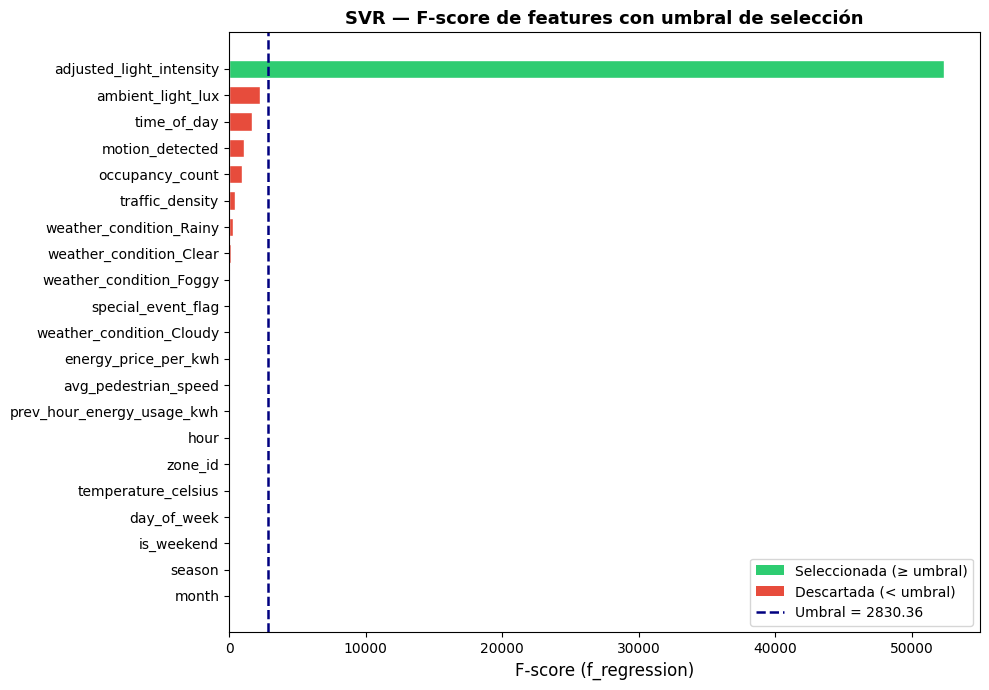

In [20]:
# Gráfica de F-scores con línea de umbral
feature_fscore_df = pd.DataFrame({
    'feature': X.columns,
    'fscore' : f_scores
}).sort_values('fscore', ascending=True)

colores_svr = ['#2ecc71' if sc >= umbral_svr else '#e74c3c'
               for sc in feature_fscore_df['fscore']]

plt.figure(figsize=(10, 7))
plt.barh(feature_fscore_df['feature'], feature_fscore_df['fscore'],
         color=colores_svr, edgecolor='white', height=0.7)
plt.axvline(x=umbral_svr, color='navy', linestyle='--', linewidth=1.8,
            label=f'Umbral (mean = {umbral_svr:.2f})')
plt.xlabel('F-score (f_regression)', fontsize=12)
plt.title('SVR — F-score de features con umbral de selección',
          fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Seleccionada (≥ umbral)'),
    Patch(facecolor='#e74c3c', label='Descartada (< umbral)'),
    plt.Line2D([0], [0], color='navy', linestyle='--',
               linewidth=1.8, label=f'Umbral = {umbral_svr:.2f}')
]
plt.legend(handles=legend_elements, fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

In [21]:
# Reentrenar SVR con los hiperparámetros optimizados y las features seleccionadas
t0 = time.time()
svr_fs = SVR(
    C       = grid_search_svr.best_params_['C'],
    epsilon = grid_search_svr.best_params_['epsilon'],
    kernel  = grid_search_svr.best_params_['kernel'],
    gamma   = grid_search_svr.best_params_['gamma']
)
svr_fs.fit(X_train_svr_fs, y_train)

# Predicciones
y_pred_svr_fs = svr_fs.predict(X_test_svr_fs)

n_features_total = X_train.shape[1]
print("RESULTADOS SVR — CON SELECCIÓN POR F-SCORE")
print(f"Features usadas : {len(features_seleccionadas_svr)} de {n_features_total}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_svr_fs):.4f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred_svr_fs):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_svr_fs)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred_svr_fs):.4f}")
print(f"MAPE : {mean_absolute_percentage_error(y_test, y_pred_svr_fs)*100:.2f}%")
print(f"Tiempo de entrenamiento: {time.time()-t0:.2f}s")

RESULTADOS SVR — CON SELECCIÓN POR F-SCORE
Features usadas : 1 de 21
MAE  : 0.1717
MSE  : 0.0468
RMSE : 0.2164
R²   : 0.8413
MAPE : 186920205263156.34%
Tiempo de entrenamiento: 3.66s


In [22]:
# Comparación: SVR completo vs SVR con selección por F-score
comparacion_svr_fs = pd.DataFrame({
    'Modelo'      : [
        'SVR Optimizado (todas las features)',
        f'SVR + F-score ({len(features_seleccionadas_svr)} features, umbral=mean)'
    ],
    'N° Features' : [n_features_total, len(features_seleccionadas_svr)],
    'MAE'         : [mean_absolute_error(y_test, y_pred_svr_best),
                     mean_absolute_error(y_test, y_pred_svr_fs)],
    'RMSE'        : [np.sqrt(mean_squared_error(y_test, y_pred_svr_best)),
                     np.sqrt(mean_squared_error(y_test, y_pred_svr_fs))],
    'R²'          : [r2_score(y_test, y_pred_svr_best),
                     r2_score(y_test, y_pred_svr_fs)],
    'MAPE (%)'    : [mean_absolute_percentage_error(y_test, y_pred_svr_best)*100,
                     mean_absolute_percentage_error(y_test, y_pred_svr_fs)*100]
})

print("Comparación SVR — todas las features vs Selección por F-score:")
print(comparacion_svr_fs.round(4).to_string(index=False))

Comparación SVR — todas las features vs Selección por F-score:
                                 Modelo  N° Features    MAE   RMSE     R²     MAPE (%)
    SVR Optimizado (todas las features)           21 0.1639 0.2063 0.8557 1.723142e+14
SVR + F-score (1 features, umbral=mean)            1 0.1717 0.2164 0.8413 1.869202e+14


### 13.2 Validación cruzada — SVR con todas las features

In [23]:
cv_5fold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring_metrics_reg = {
    'mae'  : 'neg_mean_absolute_error',
    'rmse' : 'neg_root_mean_squared_error',
    'r2'   : 'r2'
}

t0 = time.time()

cv_results_svr_completo = cross_validate(
    svr_best,
    X_train_scaled, y_train,    # SVR requiere datos escalados
    cv=cv_5fold,
    scoring=scoring_metrics_reg,
    n_jobs=-1,
    return_train_score=True     # Permite detectar overfitting
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — SVR TODAS LAS FEATURES")
for metrica, key in [('MAE', 'mae'), ('RMSE', 'rmse'), ('R²', 'r2')]:
    val_scores   = cv_results_svr_completo[f'test_{key}']
    train_scores = cv_results_svr_completo[f'train_{key}']
    factor = -1 if key in ['mae', 'rmse'] else 1
    print(f"  {metrica:5s} | Val: {factor*val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {factor*train_scores.mean():.4f} ± {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


RESULTADOS VALIDACIÓN CRUZADA — SVR TODAS LAS FEATURES
  MAE   | Val: 0.1606 ± 0.0017 | Train: 0.1599 ± 0.0004
  RMSE  | Val: 0.2009 ± 0.0026 | Train: 0.2003 ± 0.0006
  R²    | Val: 0.8599 ± 0.0048 | Train: 0.8608 ± 0.0012

Tiempo: 18.5s


### 13.3 Validación cruzada — SVR con selección de características

In [24]:
t0 = time.time()
# Validación cruzada con el modelo SVR entrenado solo con las features
# seleccionadas por F-score (umbral = mean)
cv_results_svr_fs = cross_validate(
    svr_fs,
    X_train_svr_fs, y_train,    # Subconjunto ya transformado por SelectKBest
    cv=cv_5fold,
    scoring=scoring_metrics_reg,
    n_jobs=-1,
    return_train_score=True
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — SVR CON SELECCIÓN POR F-SCORE")
for metrica, key in [('MAE', 'mae'), ('RMSE', 'rmse'), ('R²', 'r2')]:
    val_scores   = cv_results_svr_fs[f'test_{key}']
    train_scores = cv_results_svr_fs[f'train_{key}']
    factor = -1 if key in ['mae', 'rmse'] else 1
    print(f"  {metrica:5s} | Val: {factor*val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {factor*train_scores.mean():.4f} ± {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


RESULTADOS VALIDACIÓN CRUZADA — SVR CON SELECCIÓN POR F-SCORE
  MAE   | Val: 0.1687 ± 0.0024 | Train: 0.1685 ± 0.0006
  RMSE  | Val: 0.2114 ± 0.0032 | Train: 0.2113 ± 0.0008
  R²    | Val: 0.8449 ± 0.0054 | Train: 0.8451 ± 0.0013

Tiempo: 8.4s


### 13.4 Comparación de la validación cruzada — SVR

In [25]:
metricas_cv  = ['mae', 'rmse', 'r2']
nombres_show = ['MAE', 'RMSE', 'R²']
# Las métricas neg_* se invierten para mostrar valores positivos
factores     = [-1, -1, 1]

resumen_cv_svr = pd.DataFrame({
    'Métrica'            : nombres_show,
    'SVR_Completo_Media' : [factores[i] * cv_results_svr_completo[f'test_{m}'].mean()
                            for i, m in enumerate(metricas_cv)],
    'SVR_Completo_Std'   : [cv_results_svr_completo[f'test_{m}'].std()
                            for m in metricas_cv],
    'SVR_FS_Media'       : [factores[i] * cv_results_svr_fs[f'test_{m}'].mean()
                            for i, m in enumerate(metricas_cv)],
    'SVR_FS_Std'         : [cv_results_svr_fs[f'test_{m}'].std()
                            for m in metricas_cv],
})

print("COMPARACIÓN VALIDACIÓN CRUZADA — SVR Completo vs SVR + F-score")
print(resumen_cv_svr.round(4).to_string(index=False))

COMPARACIÓN VALIDACIÓN CRUZADA — SVR Completo vs SVR + F-score
Métrica  SVR_Completo_Media  SVR_Completo_Std  SVR_FS_Media  SVR_FS_Std
    MAE              0.1606            0.0017        0.1687      0.0024
   RMSE              0.2009            0.0026        0.2114      0.0032
     R²              0.8599            0.0048        0.8449      0.0054


## 14. Comparación final con validación cruzada

Se comparan los 4 modelos en:
1. Métricas en test set: modelos completos y con selección de features
2. Validación cruzada 5-fold: comparación de MAE, RMSE y R²
3. Número de features seleccionadas por cada método

### 14.1 Comparación de métricas en test set

In [ ]:
# TODO: Tabla comparativa final — todos los modelos (completos + con FS)
# Métricas: MAE, RMSE, R², MAPE
pass

### 14.2 Selección de variables

In [ ]:
# TODO: Resumen del número de features seleccionadas por cada modelo
pass

### 14.3 Validación cruzada

In [ ]:
# TODO: Tabla comparativa CV — los 4 modelos (completo + con FS)
pass

### 14.4 Gráficos de Validación Cruzada: RMSE y R²

In [ ]:
# TODO: Gráficos comparativos de CV (RMSE y R²) para los 4 modelos
pass

## 15. Guardar modelos

*(Pendiente — se activará cuando todos los modelos estén finalizados)*

In [ ]:
# guardar modelos
# import pickle

# with open('modelo_xgb_regressor.pkl', 'wb') as f:
#     pickle.dump(xgb_best, f)

# with open('modelo_xgb_fs_regressor.pkl', 'wb') as f:
#     pickle.dump(xgb_fs, f)

# with open('scaler_smartlighting.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# print("Modelos guardados correctamente")